# Optogenetics — Visualization

This notebook loads the previously built combined DataFrame (see `optogenetics_build_dataframe.ipynb`) and runs the visualization / exploration workflows.

In [ ]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

In [ ]:
from nwb_utils import NWBUtils
from optogenetics_utils import (
    create_opto_data_frame,
    find_unique_combinations,
    find_unique_stimulation,
    load_opto_data_frame,
    find_unique_values_by_conditions,
    normalize_string_columns,
)
from optogenetics_visualization import (
    plot_stay_switch_over_window,
    plot_rates_vs_latent,
)

## Load the pre-built combined DataFrame

In [ ]:
combined_dataframe = load_opto_data_frame(
    csv_path='/root/capsule/scratch/combined_opto_data_frame.csv'
)
combined_dataframe = normalize_string_columns(combined_dataframe)
combined_dataframe.shape

## Inspect unique stimulation conditions

In [ ]:
find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={"laser_1_target_areas":["left VP GABAergic neuron inactivation"],"laser_2_target_areas":["right VP GABAergic neuron inactivation"]}
    
)

In [ ]:
conds = {"laser_start": "Go cue", "laser_end": "Trial start"}
unique_vals = find_unique_values_by_conditions(combined_dataframe, conds, output_column="session")
print(unique_vals)

## Build a `criteria` dict from one stimulation row

In [80]:
import pandas as pd

conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)


conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP->MD stimulation"],
        "laser_2_target_areas": ["right VP->MD stimulation"],
    },
)


	

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left ALM inactivation"],
        "laser_2_target_areas": ["right ALM inactivation"],
    },
)
'''


'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location','session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)
'''


conditions = conditions.sort_values(
    by=["laser_1_target_areas", "laser_2_target_areas", "session_wide_control", "n_trials"],
    ascending=[True, False, False, False],
)

row = conditions.loc[4]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 3.0,
 'laser_start': 'go cue',
 'laser_start_offset': 0.0,
 'laser_end': None,
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 20.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'off',
 'fraction_of_session': 0.5,
 'session_start_with': 'on',
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP->MD stimulation',
 'laser_2_target_areas': 'right VP->MD stimulation',
 'laser_rampingdown': 0.5}

In [81]:
conditions

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,...,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,NaN,9574,22,9
1,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,250,12,7
2,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,234,11,6
3,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.5,214,11,3
4,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.5,202,11,3
5,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,202,10,6
6,1,473.0,both,2.0,trial start,0.0,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,174,9,3
7,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.5,162,10,3
8,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,149,8,4
9,1,473.0,both,1.0,go cue,0.3,NaN,0.0,sine,20.0,...,off,0.5,on,on,left VP->MD stimulation,right VP->MD stimulation,0.2,16,1,1


## Plot rates vs. a latent variable (ITI delay sum)

In [ ]:
figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="ITI_delay_sum",
    line_by="all",
    bins=9,
    binning="uniform",
    criteria=criteria,
    latent_range=(0, 15),
    window=[-1, 2],
)

## Stay/switch over window + rates vs. deltaQ

In [101]:

row = conditions.loc[2]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 50.0,
 'laser_start': 'trial start',
 'laser_start_offset': 0.0,
 'laser_end': 'go cue',
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 20.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'off',
 'fraction_of_session': 0.5,
 'session_start_with': 'on',
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP->MD stimulation',
 'laser_2_target_areas': 'right VP->MD stimulation',
 'laser_rampingdown': 0.2}

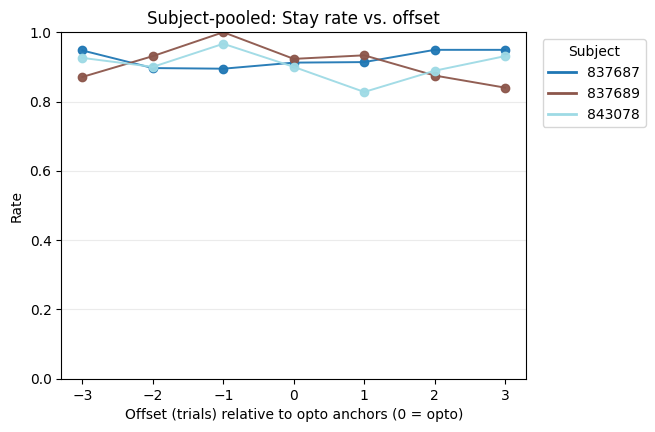

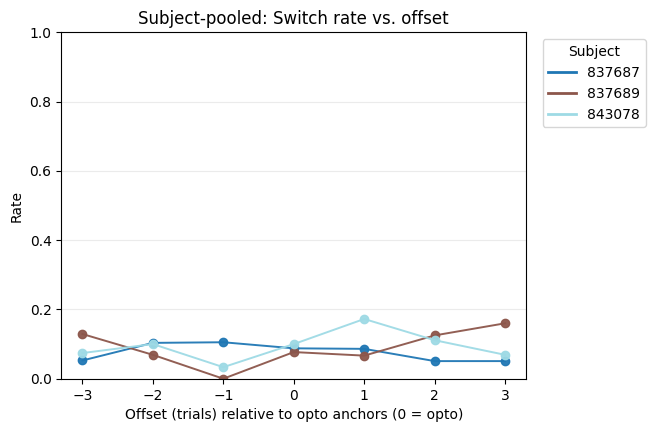

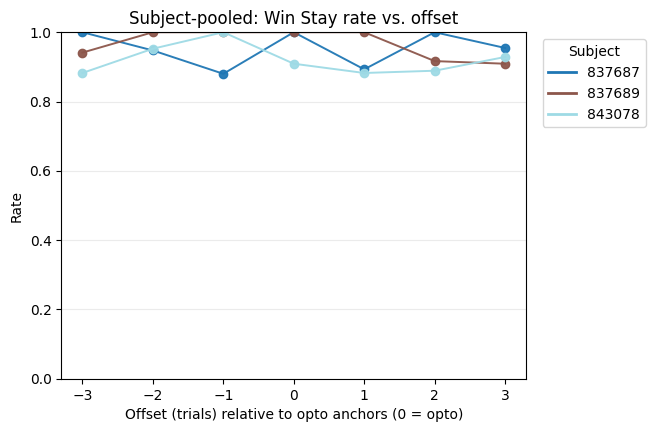

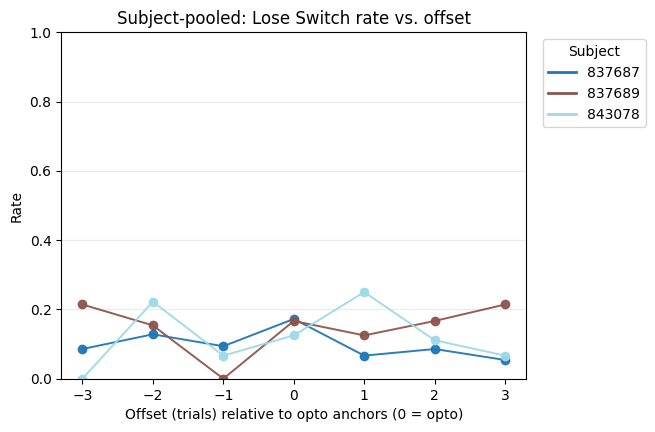

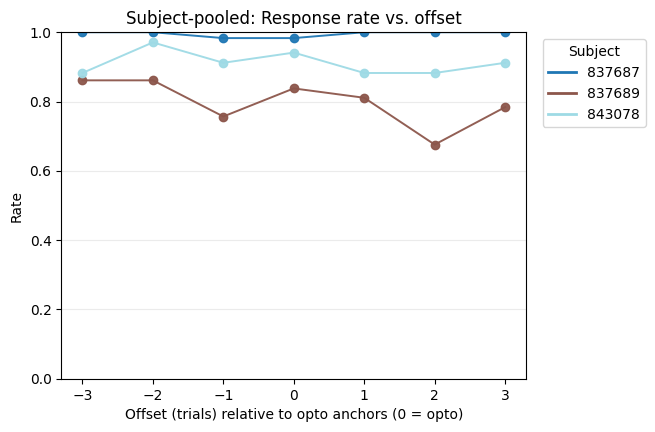

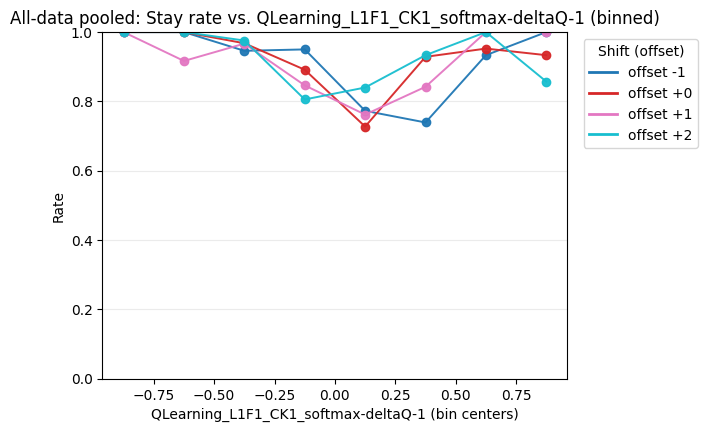

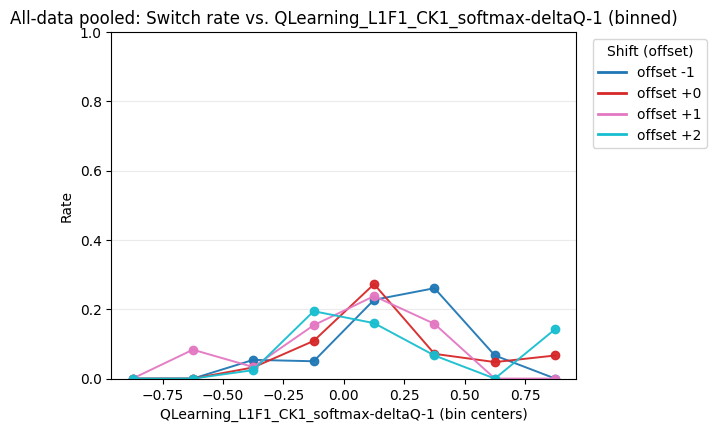

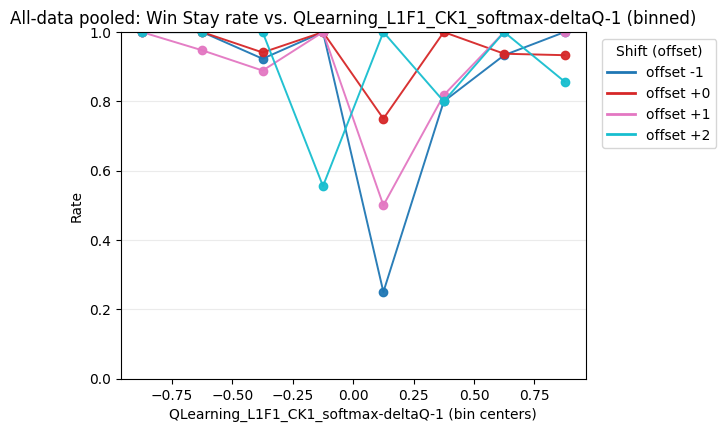

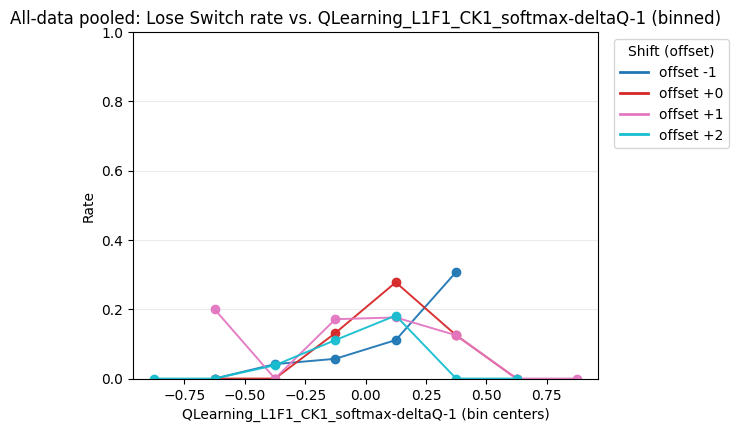

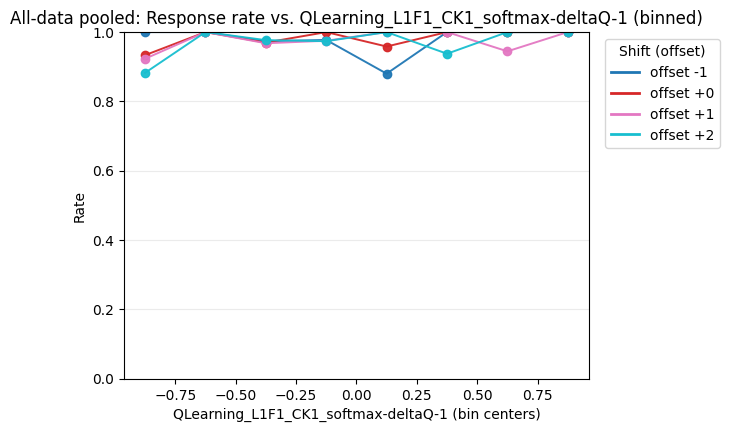

In [105]:
plot_stay_switch_over_window(
    combined_dataframe,
    criteria=criteria,
    window=[-3, 3],
    line_by='subject',
    exclude={'subject_id':[779310,795396,795710]}
)

figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="QLearning_L1F1_CK1_softmax-deltaQ-1",
    line_by="all",
    bins=8,
    binning="uniform",
    criteria=criteria,
    window=[-1, 2],
    #exclude={'subject_id':[844033,778149]}
)

{'stay': <Figure size 500x450 with 1 Axes>,
 'switch': <Figure size 500x450 with 1 Axes>,
 'win_stay': <Figure size 500x450 with 1 Axes>,
 'lose_switch': <Figure size 500x450 with 1 Axes>,
 'response': <Figure size 500x450 with 1 Axes>}

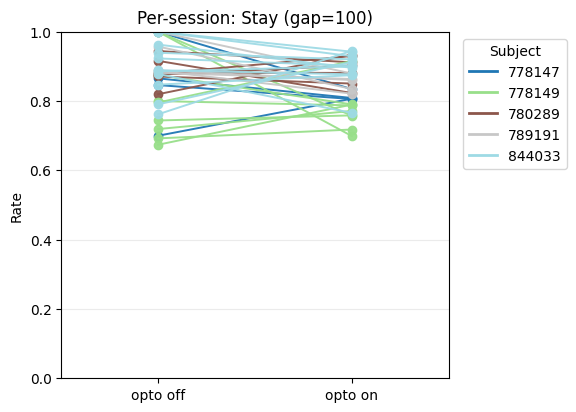

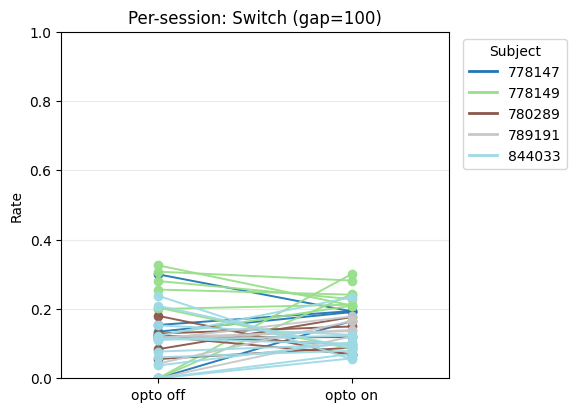

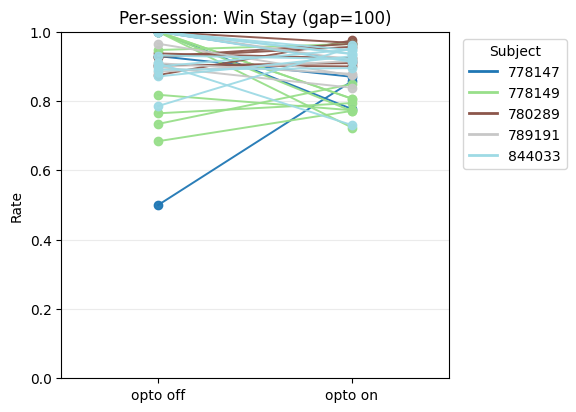

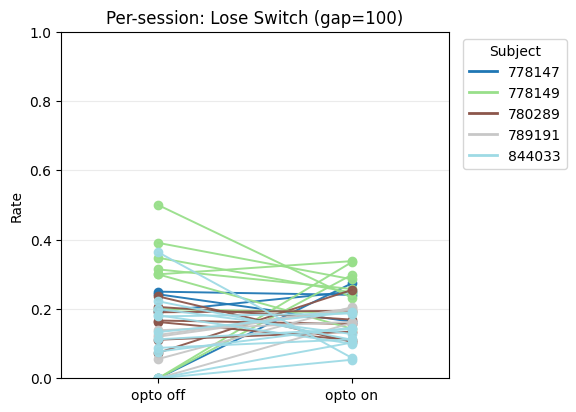

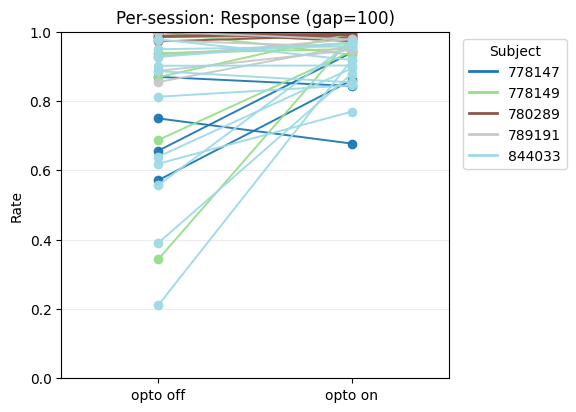

In [75]:
plot_on_off_block_rates(
    combined_dataframe,
    criteria=criteria,
    line_by='session',
)